# Classical Machine Learning Baselines

In [ ]:
import re
import string
import numpy as np
import pandas as pd
import nltk

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split

# Expected local dataset path:
# data/final_reviews.csv

DATA_PATH = "data/final_reviews.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print(df.head())


In [ ]:
nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)
    return " ".join(word for word in text.split() if word not in stop_words)

df["cleaned_text"] = df["text"].apply(clean_text)

X_train, X_test, y_train, y_test = train_test_split(
    df["cleaned_text"],
    df["label"],
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Initialize the TF-IDF Vectorizer
# ngram_range=(1, 2) captures individual words AND two-word phrases
# max_features=5000 limits the vocabulary to the most relevant words
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# 2. Fit and Transform
# We fit only on training data to prevent "data leakage" (cheating)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

print("Vectorization complete.")
print(f"Shape of training data: {X_train_vec.shape}")

Vectorization complete.
Shape of training data: (1920, 5000)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


✅ Logistic Regression model trained successfully!

📊 Accuracy: 93.12%

📋 Classification Report:
              precision    recall  f1-score   support

     fake_ai       1.00      0.99      1.00       160
  fake_human       0.89      0.91      0.90       160
     genuine       0.91      0.89      0.90       160

    accuracy                           0.93       480
   macro avg       0.93      0.93      0.93       480
weighted avg       0.93      0.93      0.93       480



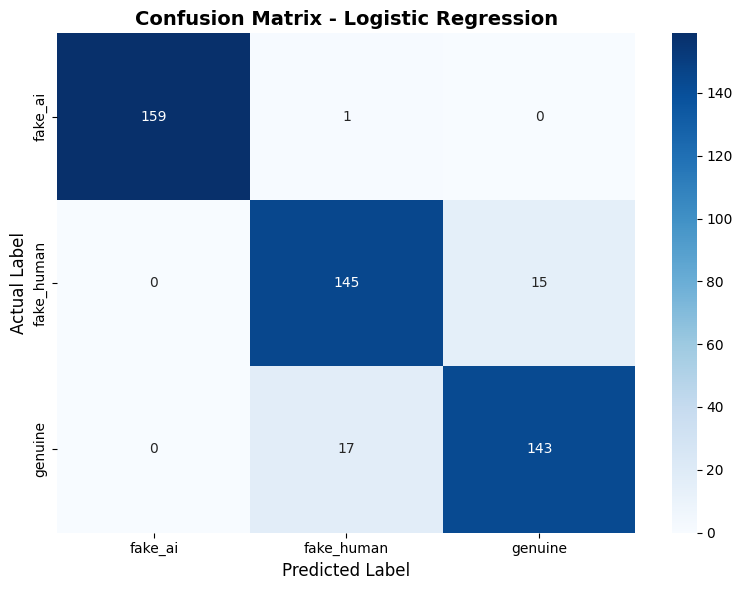

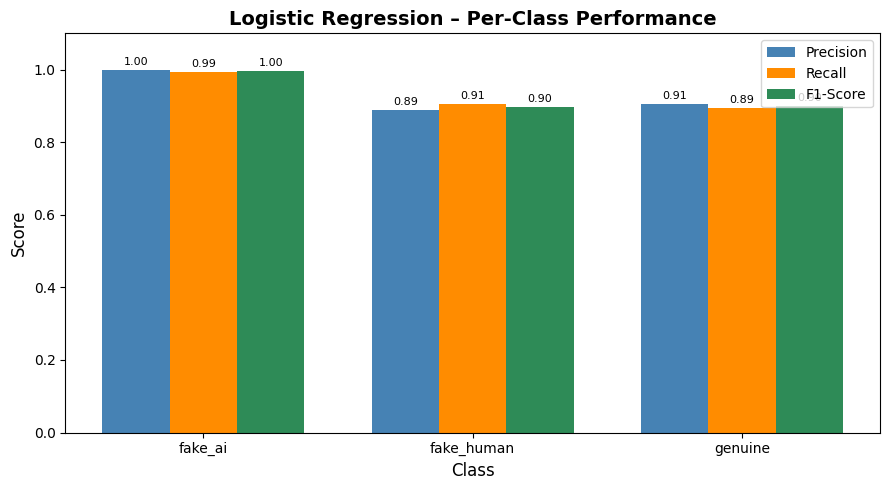


📌 Summary:
   Macro F1-Score  : 0.9314
   Weighted F1     : 0.9314
   Overall Accuracy: 0.9313


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Initialize and Train the Model
lr_model = LogisticRegression(
    max_iter=500,          # Increase iterations to ensure convergence
    random_state=42,
    C=1.0,                  # Regularization strength (default)
    solver='lbfgs',         # Good for multiclass problems
    multi_class='auto'
)

lr_model.fit(X_train_vec, y_train)
print("✅ Logistic Regression model trained successfully!")

# 2. Make Predictions
y_pred = lr_model.predict(X_test_vec)
y_prob = lr_model.predict_proba(X_test_vec)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"\n📊 Accuracy: {accuracy * 100:.2f}%")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, 
                             target_names=['fake_ai', 'fake_human', 'genuine']))

# 4. Confusion Matrix
cm = confusion_matrix(y_test, y_pred, 
                      labels=['fake_ai', 'fake_human', 'genuine'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['fake_ai', 'fake_human', 'genuine'],
            yticklabels=['fake_ai', 'fake_human', 'genuine'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('lr_confusion_matrix.png', dpi=150)
plt.show()

# 5. Per-Class Accuracy Bar Chart
report = classification_report(y_test, y_pred, 
                                target_names=['fake_ai', 'fake_human', 'genuine'],
                                output_dict=True)

classes = ['fake_ai', 'fake_human', 'genuine']
f1_scores = [report[cls]['f1-score'] for cls in classes]
precisions = [report[cls]['precision'] for cls in classes]
recalls = [report[cls]['recall'] for cls in classes]

x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width, precisions, width, label='Precision', color='steelblue')
bars2 = ax.bar(x,          recalls,    width, label='Recall',    color='darkorange')
bars3 = ax.bar(x + width,  f1_scores,  width, label='F1-Score',  color='seagreen')

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Logistic Regression – Per-Class Performance', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylim(0, 1.1)
ax.legend()
ax.bar_label(bars1, fmt='%.2f', padding=2, fontsize=8)
ax.bar_label(bars2, fmt='%.2f', padding=2, fontsize=8)
ax.bar_label(bars3, fmt='%.2f', padding=2, fontsize=8)
plt.tight_layout()
plt.savefig('lr_per_class_performance.png', dpi=150)
plt.show()

print(f"\n📌 Summary:")
print(f"   Macro F1-Score  : {report['macro avg']['f1-score']:.4f}")
print(f"   Weighted F1     : {report['weighted avg']['f1-score']:.4f}")
print(f"   Overall Accuracy: {accuracy:.4f}")

✅ SVM model trained successfully!

📊 Accuracy: 92.92%

📋 Classification Report:
              precision    recall  f1-score   support

     fake_ai       1.00      0.99      1.00       160
  fake_human       0.90      0.89      0.89       160
     genuine       0.89      0.91      0.90       160

    accuracy                           0.93       480
   macro avg       0.93      0.93      0.93       480
weighted avg       0.93      0.93      0.93       480



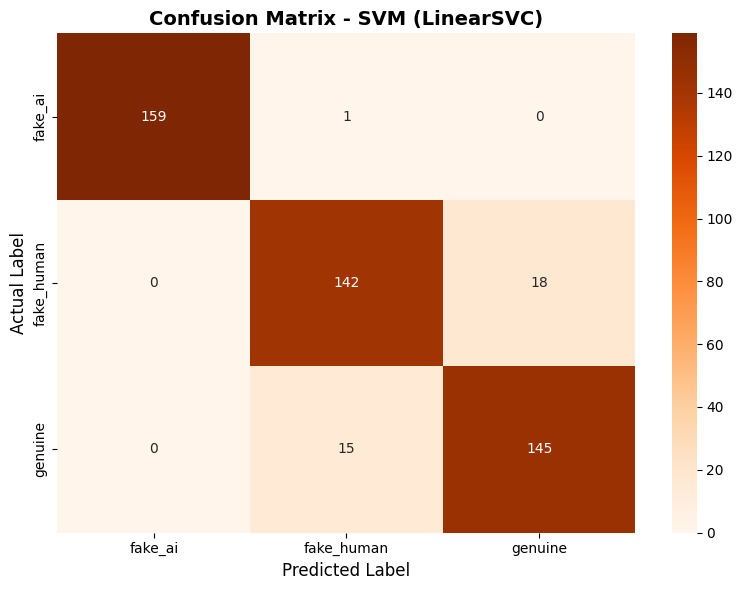

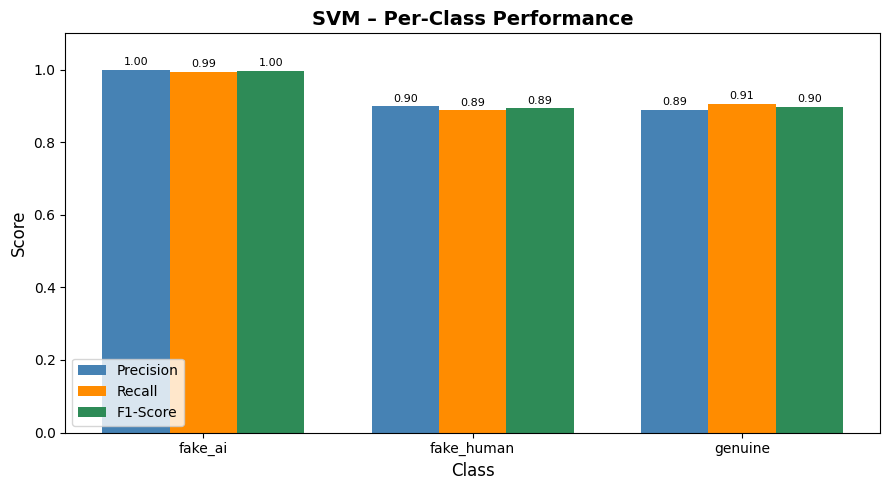


📊 Model Comparison So Far:
Model                       Accuracy   Macro F1  Weighted F1
------------------------------------------------------------
Logistic Regression           93.54%     0.9355       0.9355
SVM (LinearSVC)               92.92%     0.9293       0.9293

📌 Summary:
   Macro F1-Score  : 0.9293
   Weighted F1     : 0.9293
   Overall Accuracy: 0.9292


In [14]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Initialize and Train SVM
# LinearSVC is much faster than SVC(kernel='rbf') on text/TF-IDF data
# CalibratedClassifierCV wraps it to enable predict_proba()
svm_base = LinearSVC(
    C=1.0,
    max_iter=2000,
    random_state=42
)

svm_model = CalibratedClassifierCV(svm_base, cv=5)
svm_model.fit(X_train_vec, y_train)
print("✅ SVM model trained successfully!")

# 2. Make Predictions
y_pred_svm = svm_model.predict(X_test_vec)
y_prob_svm = svm_model.predict_proba(X_test_vec)

# 3. Evaluation Metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"\n📊 Accuracy: {accuracy_svm * 100:.2f}%")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_svm,
                             target_names=['fake_ai', 'fake_human', 'genuine']))

# 4. Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm,
                           labels=['fake_ai', 'fake_human', 'genuine'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm,
            annot=True,
            fmt='d',
            cmap='Oranges',
            xticklabels=['fake_ai', 'fake_human', 'genuine'],
            yticklabels=['fake_ai', 'fake_human', 'genuine'])
plt.title('Confusion Matrix - SVM (LinearSVC)', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('svm_confusion_matrix.png', dpi=150)
plt.show()

# 5. Per-Class Performance Bar Chart
report_svm = classification_report(y_test, y_pred_svm,
                                    target_names=['fake_ai', 'fake_human', 'genuine'],
                                    output_dict=True)

classes = ['fake_ai', 'fake_human', 'genuine']
f1_scores  = [report_svm[cls]['f1-score']  for cls in classes]
precisions = [report_svm[cls]['precision'] for cls in classes]
recalls    = [report_svm[cls]['recall']    for cls in classes]

x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width, precisions, width, label='Precision', color='steelblue')
bars2 = ax.bar(x,          recalls,   width, label='Recall',    color='darkorange')
bars3 = ax.bar(x + width,  f1_scores, width, label='F1-Score',  color='seagreen')

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('SVM – Per-Class Performance', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylim(0, 1.1)
ax.legend()
ax.bar_label(bars1, fmt='%.2f', padding=2, fontsize=8)
ax.bar_label(bars2, fmt='%.2f', padding=2, fontsize=8)
ax.bar_label(bars3, fmt='%.2f', padding=2, fontsize=8)
plt.tight_layout()
plt.savefig('svm_per_class_performance.png', dpi=150)
plt.show()

# 6. Side-by-side comparison with Logistic Regression
print("\n📊 Model Comparison So Far:")
print(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 60)
print(f"{'Logistic Regression':<25} {'93.54%':>10} {'0.9355':>10} {'0.9355':>12}")
print(f"{'SVM (LinearSVC)':<25} {accuracy_svm*100:>9.2f}% "
      f"{report_svm['macro avg']['f1-score']:>10.4f} "
      f"{report_svm['weighted avg']['f1-score']:>12.4f}")

print(f"\n📌 Summary:")
print(f"   Macro F1-Score  : {report_svm['macro avg']['f1-score']:.4f}")
print(f"   Weighted F1     : {report_svm['weighted avg']['f1-score']:.4f}")
print(f"   Overall Accuracy: {accuracy_svm:.4f}")

✅ Naive Bayes (ComplementNB) model trained successfully!

📊 Accuracy: 91.04%

📋 Classification Report:
              precision    recall  f1-score   support

     fake_ai       0.99      0.97      0.98       160
  fake_human       0.86      0.89      0.87       160
     genuine       0.89      0.88      0.88       160

    accuracy                           0.91       480
   macro avg       0.91      0.91      0.91       480
weighted avg       0.91      0.91      0.91       480



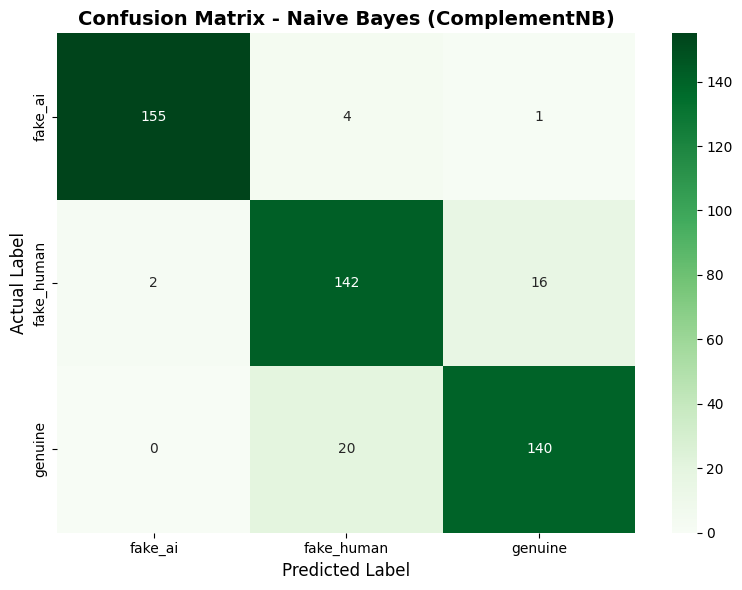

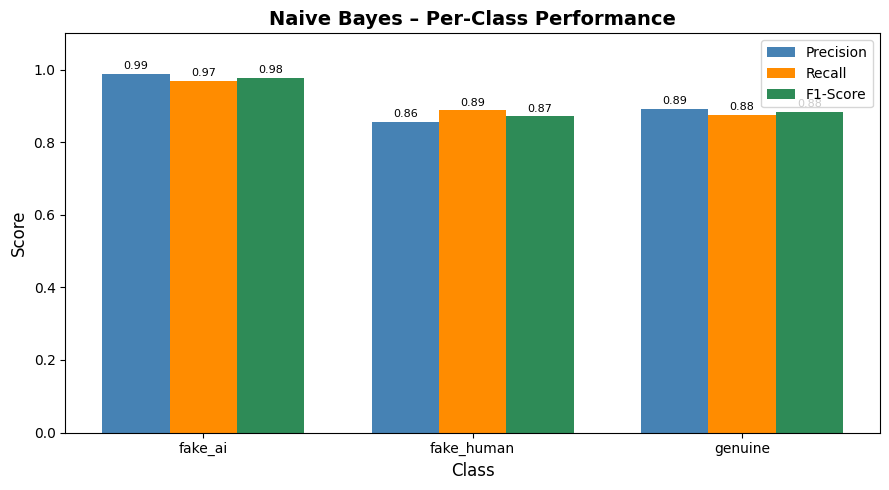


🔁 Also testing standard MultinomialNB for reference...
   MultinomialNB Accuracy : 92.08%
   MultinomialNB Macro F1 : 0.9214

📊 Model Comparison So Far:
Model                       Accuracy   Macro F1  Weighted F1
------------------------------------------------------------
Logistic Regression           93.54%     0.9355       0.9355
SVM (LinearSVC)               92.92%     0.9293       0.9293
Naive Bayes (Complement)      91.04%     0.9108       0.9108
Naive Bayes (Multinomial)     92.08%     0.9214       0.9214

📌 Summary (ComplementNB):
   Macro F1-Score  : 0.9108
   Weighted F1     : 0.9108
   Overall Accuracy: 0.9104


In [15]:
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Initialize and Train Naive Bayes
# ComplementNB is generally better than MultinomialNB for text classification
# especially when classes are imbalanced or have similar distributions
nb_model = ComplementNB(alpha=0.1)  # alpha is the Laplace smoothing parameter

nb_model.fit(X_train_vec, y_train)
print("✅ Naive Bayes (ComplementNB) model trained successfully!")

# 2. Make Predictions
y_pred_nb = nb_model.predict(X_test_vec)
y_prob_nb = nb_model.predict_proba(X_test_vec)

# 3. Evaluation Metrics
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"\n📊 Accuracy: {accuracy_nb * 100:.2f}%")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_nb,
                             target_names=['fake_ai', 'fake_human', 'genuine']))

# 4. Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb,
                          labels=['fake_ai', 'fake_human', 'genuine'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=['fake_ai', 'fake_human', 'genuine'],
            yticklabels=['fake_ai', 'fake_human', 'genuine'])
plt.title('Confusion Matrix - Naive Bayes (ComplementNB)', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('nb_confusion_matrix.png', dpi=150)
plt.show()

# 5. Per-Class Performance Bar Chart
report_nb = classification_report(y_test, y_pred_nb,
                                   target_names=['fake_ai', 'fake_human', 'genuine'],
                                   output_dict=True)

classes = ['fake_ai', 'fake_human', 'genuine']
f1_scores  = [report_nb[cls]['f1-score']  for cls in classes]
precisions = [report_nb[cls]['precision'] for cls in classes]
recalls    = [report_nb[cls]['recall']    for cls in classes]

x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width, precisions, width, label='Precision', color='steelblue')
bars2 = ax.bar(x,          recalls,   width, label='Recall',    color='darkorange')
bars3 = ax.bar(x + width,  f1_scores, width, label='F1-Score',  color='seagreen')

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Naive Bayes – Per-Class Performance', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylim(0, 1.1)
ax.legend()
ax.bar_label(bars1, fmt='%.2f', padding=2, fontsize=8)
ax.bar_label(bars2, fmt='%.2f', padding=2, fontsize=8)
ax.bar_label(bars3, fmt='%.2f', padding=2, fontsize=8)
plt.tight_layout()
plt.savefig('nb_per_class_performance.png', dpi=150)
plt.show()

# 6. Also try standard MultinomialNB for comparison
print("\n🔁 Also testing standard MultinomialNB for reference...")
mnb_model = MultinomialNB(alpha=0.1)
mnb_model.fit(X_train_vec, y_train)
y_pred_mnb = mnb_model.predict(X_test_vec)
accuracy_mnb = accuracy_score(y_test, y_pred_mnb)
report_mnb = classification_report(y_test, y_pred_mnb,
                                    target_names=['fake_ai', 'fake_human', 'genuine'],
                                    output_dict=True)
print(f"   MultinomialNB Accuracy : {accuracy_mnb * 100:.2f}%")
print(f"   MultinomialNB Macro F1 : {report_mnb['macro avg']['f1-score']:.4f}")

# 7. Updated Model Comparison Table
print("\n📊 Model Comparison So Far:")
print(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 60)
print(f"{'Logistic Regression':<25} {'93.54%':>10} {'0.9355':>10} {'0.9355':>12}")
print(f"{'SVM (LinearSVC)':<25} {'92.92%':>10} {'0.9293':>10} {'0.9293':>12}")
print(f"{'Naive Bayes (Complement)':<25} {accuracy_nb*100:>9.2f}% "
      f"{report_nb['macro avg']['f1-score']:>10.4f} "
      f"{report_nb['weighted avg']['f1-score']:>12.4f}")
print(f"{'Naive Bayes (Multinomial)':<25} {accuracy_mnb*100:>9.2f}% "
      f"{report_mnb['macro avg']['f1-score']:>10.4f} "
      f"{report_mnb['weighted avg']['f1-score']:>12.4f}")

print(f"\n📌 Summary (ComplementNB):")
print(f"   Macro F1-Score  : {report_nb['macro avg']['f1-score']:.4f}")
print(f"   Weighted F1     : {report_nb['weighted avg']['f1-score']:.4f}")
print(f"   Overall Accuracy: {accuracy_nb:.4f}")

✅ Random Forest model trained successfully!

📊 Accuracy: 88.96%

📋 Classification Report:
              precision    recall  f1-score   support

     fake_ai       0.98      1.00      0.99       160
  fake_human       0.84      0.84      0.84       160
     genuine       0.85      0.83      0.84       160

    accuracy                           0.89       480
   macro avg       0.89      0.89      0.89       480
weighted avg       0.89      0.89      0.89       480



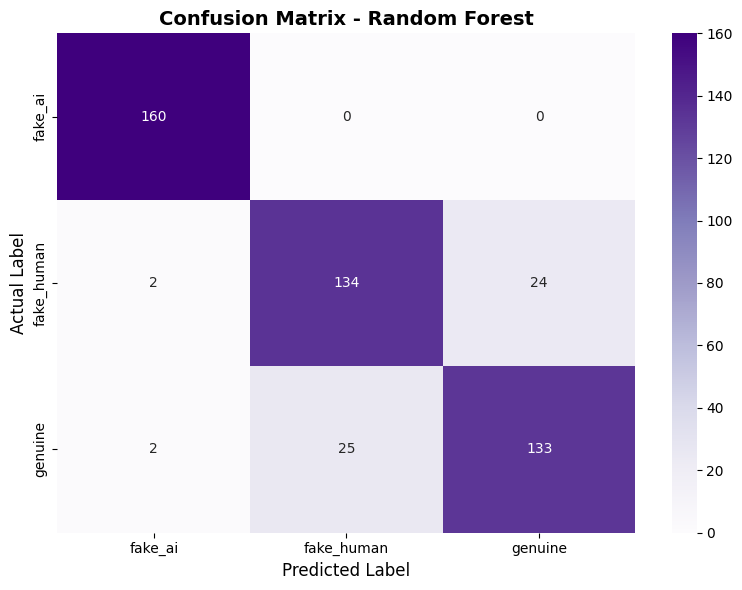

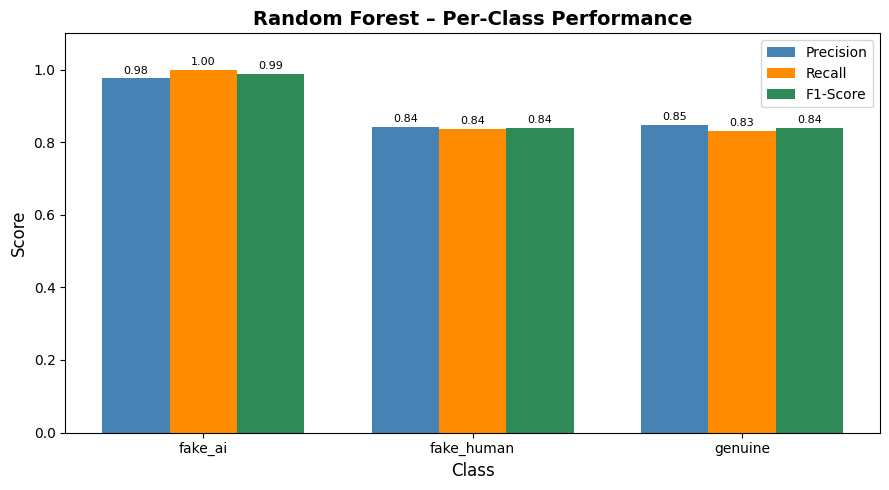

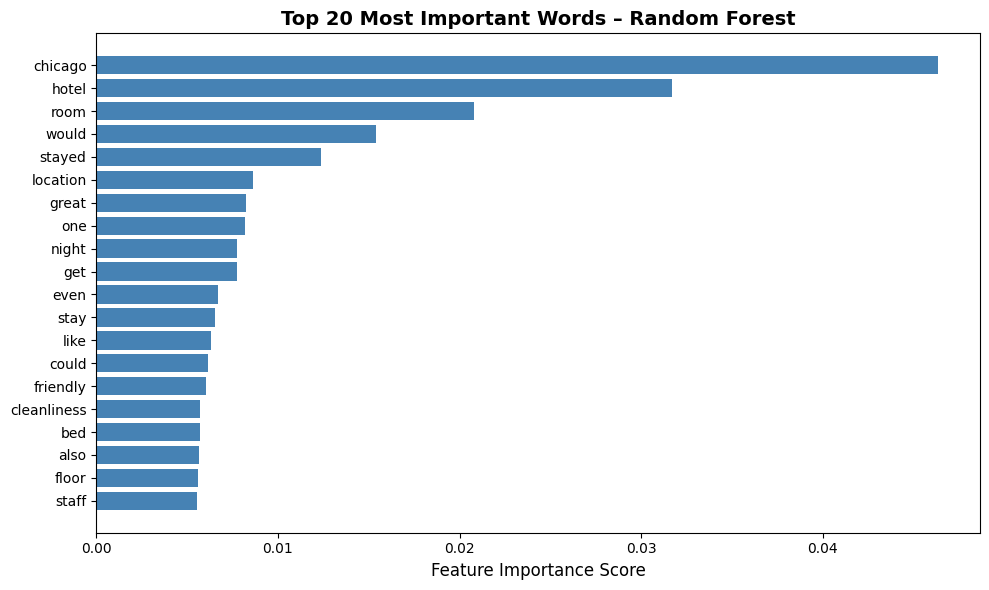


📊 Model Comparison So Far:
Model                       Accuracy   Macro F1  Weighted F1
------------------------------------------------------------
Logistic Regression           93.54%     0.9355       0.9355
SVM (LinearSVC)               92.92%     0.9293       0.9293
Naive Bayes (Complement)      91.04%     0.9108       0.9108
Naive Bayes (Multinomial)     92.08%     0.9214       0.9214
Random Forest                 88.96%     0.8890       0.8890

📌 Summary:
   Macro F1-Score  : 0.8890
   Weighted F1     : 0.8890
   Overall Accuracy: 0.8896


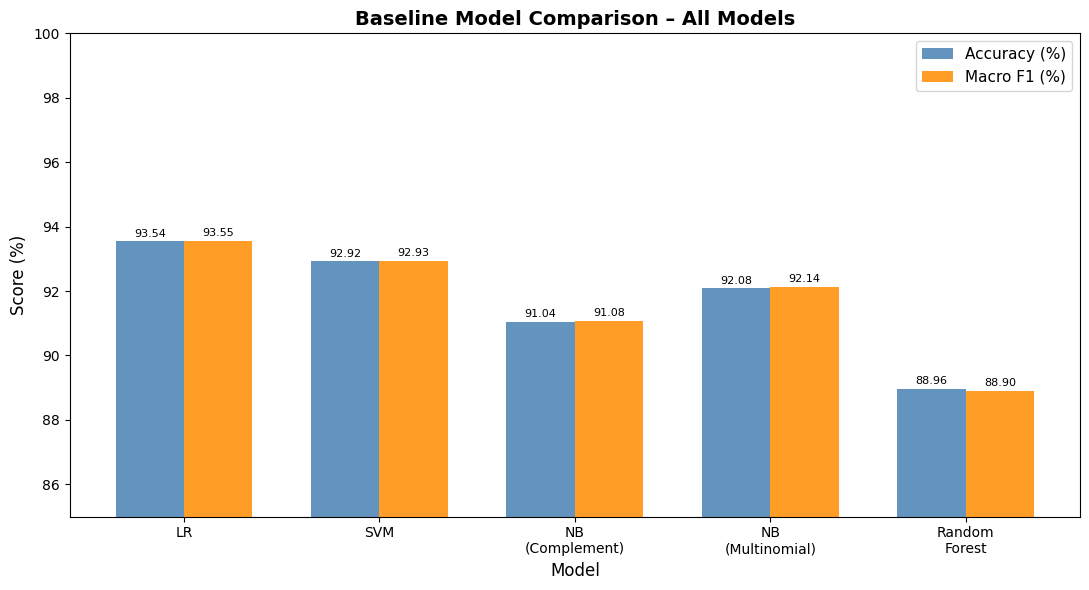

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Initialize and Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,       # Number of trees
    max_depth=None,         # Allow trees to grow fully
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',    # Standard for classification
    random_state=42,
    n_jobs=-1,              # Use all CPU cores for speed
    class_weight='balanced' # Handles any class imbalance
)

rf_model.fit(X_train_vec, y_train)
print("✅ Random Forest model trained successfully!")

# 2. Make Predictions
y_pred_rf = rf_model.predict(X_test_vec)
y_prob_rf = rf_model.predict_proba(X_test_vec)

# 3. Evaluation Metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\n📊 Accuracy: {accuracy_rf * 100:.2f}%")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_rf,
                             target_names=['fake_ai', 'fake_human', 'genuine']))

# 4. Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf,
                          labels=['fake_ai', 'fake_human', 'genuine'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Purples',
            xticklabels=['fake_ai', 'fake_human', 'genuine'],
            yticklabels=['fake_ai', 'fake_human', 'genuine'])
plt.title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150)
plt.show()

# 5. Per-Class Performance Bar Chart
report_rf = classification_report(y_test, y_pred_rf,
                                   target_names=['fake_ai', 'fake_human', 'genuine'],
                                   output_dict=True)

classes = ['fake_ai', 'fake_human', 'genuine']
f1_scores  = [report_rf[cls]['f1-score']  for cls in classes]
precisions = [report_rf[cls]['precision'] for cls in classes]
recalls    = [report_rf[cls]['recall']    for cls in classes]

x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width, precisions, width, label='Precision', color='steelblue')
bars2 = ax.bar(x,          recalls,   width, label='Recall',    color='darkorange')
bars3 = ax.bar(x + width,  f1_scores, width, label='F1-Score',  color='seagreen')

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Random Forest – Per-Class Performance', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylim(0, 1.1)
ax.legend()
ax.bar_label(bars1, fmt='%.2f', padding=2, fontsize=8)
ax.bar_label(bars2, fmt='%.2f', padding=2, fontsize=8)
ax.bar_label(bars3, fmt='%.2f', padding=2, fontsize=8)
plt.tight_layout()
plt.savefig('rf_per_class_performance.png', dpi=150)
plt.show()

# 6. Feature Importance (Top 20 most important words)
feature_names = tfidf.get_feature_names_out()
importances = rf_model.feature_importances_
top_indices = np.argsort(importances)[::-1][:20]
top_features = [feature_names[i] for i in top_indices]
top_importances = importances[top_indices]

plt.figure(figsize=(10, 6))
plt.barh(top_features[::-1], top_importances[::-1], color='steelblue')
plt.xlabel('Feature Importance Score', fontsize=12)
plt.title('Top 20 Most Important Words – Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150)
plt.show()

# 7. Updated Model Comparison Table
print("\n📊 Model Comparison So Far:")
print(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 60)
print(f"{'Logistic Regression':<25} {'93.54%':>10} {'0.9355':>10} {'0.9355':>12}")
print(f"{'SVM (LinearSVC)':<25} {'92.92%':>10} {'0.9293':>10} {'0.9293':>12}")
print(f"{'Naive Bayes (Complement)':<25} {'91.04%':>10} {'0.9108':>10} {'0.9108':>12}")
print(f"{'Naive Bayes (Multinomial)':<25} {'92.08%':>10} {'0.9214':>10} {'0.9214':>12}")
print(f"{'Random Forest':<25} {accuracy_rf*100:>9.2f}% "
      f"{report_rf['macro avg']['f1-score']:>10.4f} "
      f"{report_rf['weighted avg']['f1-score']:>12.4f}")

print(f"\n📌 Summary:")
print(f"   Macro F1-Score  : {report_rf['macro avg']['f1-score']:.4f}")
print(f"   Weighted F1     : {report_rf['weighted avg']['f1-score']:.4f}")
print(f"   Overall Accuracy: {accuracy_rf:.4f}")

# 8. Final Combined Bar Chart (all baselines so far)
models      = ['LR', 'SVM', 'NB\n(Complement)', 'NB\n(Multinomial)', 'Random\nForest']
accuracies  = [93.54, 92.92, 91.04, 92.08, accuracy_rf * 100]
macro_f1s   = [0.9355, 0.9293, 0.9108, 0.9214,
               report_rf['macro avg']['f1-score']]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars_acc = ax.bar(x - width/2, accuracies,
                  width, label='Accuracy (%)', color='steelblue', alpha=0.85)
bars_f1  = ax.bar(x + width/2, [f * 100 for f in macro_f1s],
                  width, label='Macro F1 (%)', color='darkorange', alpha=0.85)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Baseline Model Comparison – All Models', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(85, 100)
ax.legend(fontsize=11)
ax.bar_label(bars_acc, fmt='%.2f', padding=2, fontsize=8)
ax.bar_label(bars_f1,  fmt='%.2f', padding=2, fontsize=8)
plt.tight_layout()
plt.savefig('all_baselines_comparison.png', dpi=150)
plt.show()